**VERSION v3**: I used a new paradigm where the signal of each satellite has its own alpha value for fitting; I tried to keep the rest of the calculations in the code as close as possible to the original one. This second try uses the new optimization with `nnls` and tries to fit all 286 satellite signals.

### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
from scipy.optimize import lsq_linear, nnls
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [8]:
## ----- FITTING PARAMETERS ----- ##

# folder and name of final results file
folder = "results/v3_results/"

# cost function from eq. 11 (options: "C1"=radiometer, "C2"=1)
CF = "C1"

# angular mask [degrees] (options: "1F","5F" or None)
deg = None
if deg==None:  path_nearby = None
else:  path_nearby = (pm.path_data+"nearby_satellites/nearby_satellite_close_angle_"+deg+".p")

# thermal mask [kelvin] (options: 25,50,100 or None)
temp = None

# threshold pixel mask (options: 2,5,7 or None)
pix = None

# temporal mask [seconds] (options: 775-1000, 2200-2400, 5500-6200 or None)
t_slice = [None,None]


In [9]:
pm.show_parameters(CF, deg, temp, pix, t_slice, t_slice)
print()
fname = pm.my_name(folder, CF, deg, temp, pix, t_slice)
print("File with final alpha parameters will be '{}'".format(fname))


Block: 1551055211
Frequency range: 1100 - 1350 MHz

File with final alpha parameters will be 'results/v3_results/nomask_C1.p'


### 2. Setting up the simulation

We initialize the SatelliteSimulation object, which will store the information. 

Getting catalog...
Getting beam response (2GB) ...
Getting temperature factors for each signal...
Getting observational data...
Masking...


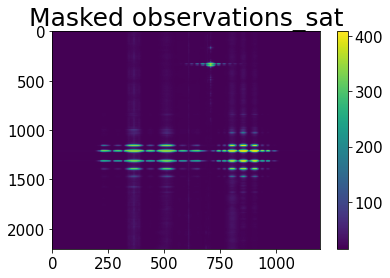

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (2203,)
 - Size of simulated Tb_factors:  (286, 1199)
 - Size of simulated sat_beam:  (73, 1199, 2203)
 - Size of observations:  (1199, 2203)


In [10]:
# initializing the simulation
sat = sim.SatelliteSimulation(
    block=str(pm.block),
    use_data=True,
    path_data=pm.path_data,
    path_beam=pm.path_data,
    survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
    path_catalog="Satellite_Catalogue/individual_satellite_constellation_catalog.csv",
    beam_model=pm.beam_model,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=t_slice,
    include_cons=["gps-ops","glo-ops","galileo","beidou","irnss","sbas"],
    verbose=False,
)

# applying mask
print("Masking...")
sat.create_mask(path_nearby, temp, pix, verbose=True)


In [11]:
# defining the cost function (only for testing, this won't be used in the optimization)
if CF=="C1":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=obs (case C1). '''
        sat.execute(alphas)
        CF = np.sum( ((sat.observations_sat-sat.simulation) / sat.observations)**2 )
        print(CF,end="\t")
        return CF
elif CF=="C2":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=1 (case C2). '''
        sat.execute(alphas)
        CF = np.sum( (sat.observations_sat-sat.simulation)**2 )
        print(CF,end="\t")
        return CF

# defining initial values (only for testing, this won't be used in the optimization)
alphas0 = np.zeros(len(sat.catalog))
_ = Cost_Function(alphas0)


117746.14337149153	

### 3. Running the optimization

We now run the optimization with the functions and parameters defined above. This part of the code **needs approximately 15GB** of memory to run the `nnls` optimization, and it takes some minutes to run the code for the creation of matrixes A and b.

In [7]:
# defining the optimization function
def optimization_setup(CF):  
    ''' Find optimal alphas with least squares weighted or not, 
    by solving the linear problem |A*alpha - b|^2 with lsq_linear. '''

    # creating matrix A
    print("Creating matrix A (6 GB) and b ...")
    A = np.empty((sat.observations_sat.size, len(sat.catalog)))
    print("    30   60   90   120  150  180  210  240  270  300")
    for j in range(len(sat.catalog)):
        if (j%6==0):  print("|", end="")
        alphas = np.zeros(len(sat.catalog))
        alphas[j] = 1.0
        sat.execute(alphas)
        A[:,j] = sat.simulation.ravel()
    b = sat.observations_sat.ravel()
        
    # defining weights if necessary
    print("\nApplying weights...")
    if CF=="C1":  
        weights = 1.0 / sat.observations.ravel()
        A *= weights[:,None]
        b *= weights

    # normalizing for faster fitting
    print("Normalizing...")
    Anorm = np.linalg.norm(A, axis=0)
    Anorm[Anorm==0] = 1
    A /= Anorm
    
    return A,b,Anorm


In [8]:
# setting up the optimization (creating matrixes A,b)
A,b,Anorm = optimization_setup(CF)

Creating matrix A (6 GB) and b ...
    30   60   90   120  150  180  210  240  270  300
||||||||||||||||||||||||||||||||||||||||||||||||
Applying weights...
Normalizing...


In [9]:
# running the optimization
start = time.perf_counter()
print("Running optimization...")
x,rnorm = nnls(
    A, b,
    maxiter=1000,
)
print("Done.")
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Running optimization...
Done.
This took 20.01 seconds, or 0.33 minutes


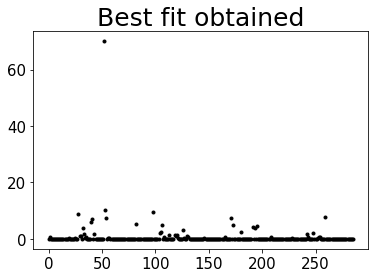

In [10]:
# saving best fit values
alphas_BF = x / Anorm

# plotting values
plt.plot(alphas_BF,"k.")
plt.title("Best fit obtained")
plt.show()

In [11]:
# saving information in the file
data_info = {
    "initial" : alphas0,
    "CF" : CF,
    "mask_degree" : deg, 
    "mask_temperature" : temp, 
    "mask_pix" : pix, 
    "time_slice" : t_slice,
    "frequency_slice" : [pm.fs_slice, pm.fe_slice], 
    "best-fit" : alphas_BF,
}

print(f"Information saved in file '{fname}'.")
pickle.dump( data_info, open(fname,"wb") )


Information saved in file 'results/v3_results/interval5500-6200_C2.p'.
